Nash Equilibrium Prices → Firm 1: $250.00, Firm 2: $250.00
Profit at Equilibrium  → Firm 1: $12500.00, Firm 2: $12500.00


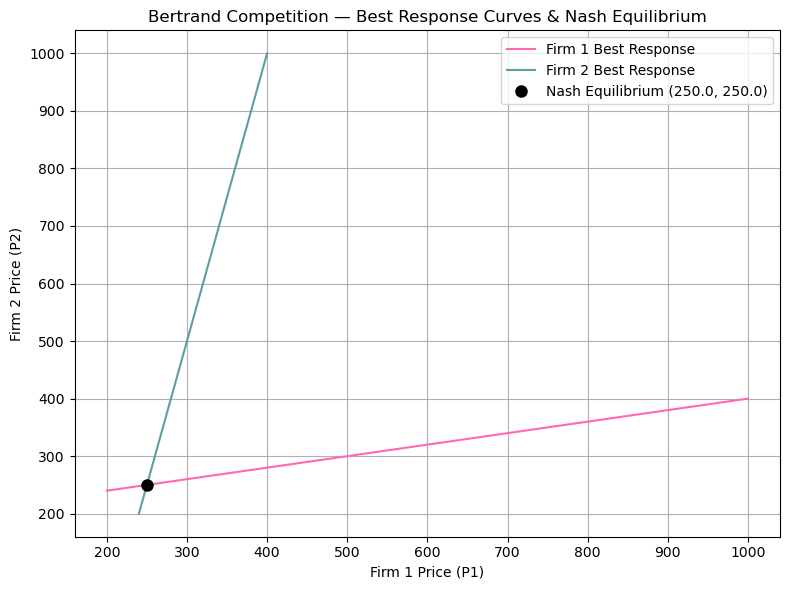

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
# parameters
a = 1000  # base demand
b = 5    # own-price sensitivity
c = 2    # cross price sensitivity
mc = 200  # same for firm 1 & 2
def profit1(p1, p2):
    q1 = a - b*p1 + c*p2
    return (p1 - mc) * q1
def profit2(p1, p2):
    q2 = a - b*p2 + c*p1  # fixed: was c*p2
    return (p2 - mc) * q2
# best response functions
def br1(p2):
    return (a + b*mc + c*p2) / (2*b)
def br2(p1):
    return (a + b*mc + c*p1) / (2*b)
# finding Nash Equilibrium
def equations(p):
    p1, p2 = p
    return [p1 - br1(p2), p2 - br2(p1)]
p1_eq, p2_eq = fsolve(equations, [500, 500])  # fixed: starting guess was too high
print(f"Nash Equilibrium Prices → Firm 1: ${p1_eq:.2f}, Firm 2: ${p2_eq:.2f}")
print(f"Profit at Equilibrium  → Firm 1: ${profit1(p1_eq, p2_eq):.2f}, Firm 2: ${profit2(p1_eq, p2_eq):.2f}")
# graph
p_range = np.linspace(mc, 1000, 200)
plt.figure(figsize=(8, 6))
plt.plot(p_range, br1(p_range), label="Firm 1 Best Response", color="hotpink")
plt.plot(br2(p_range), p_range, label="Firm 2 Best Response", color="cadetblue")
plt.plot(p1_eq, p2_eq, 'ko', markersize=8, label=f"Nash Equilibrium ({p1_eq:.1f}, {p2_eq:.1f})")
plt.xlabel("Firm 1 Price (P1)")
plt.ylabel("Firm 2 Price (P2)")
plt.title("Bertrand Competition — Best Response Curves & Nash Equilibrium")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()